# Anharmonic two-mode chromophore: fifth-order 2Q spectroscopy

This example builds a small bosonic chromophore model and calculates a fifth-order, double-quantum spectrum. It demonstrates:

- a Hilbert space organized into ground, one-exciton, and biexciton manifolds;
- anharmonic interactions between two coupled local modes;
- explicit raising and lowering operators $J_+$ and $J_-$;
- UFSS pathway generation for a five-interaction $\chi^{(5)}$ signal;
- simultaneous detection of total and mode-resolved polarizations.

Natural units are used, with $\hbar=1$. Energies are in eV and times are in eV$^{-1}$.

In [1]:
from pathlib import Path
import sys

import numpy as np
import ufss

# Locate the project root when the notebook is launched from examples/
# or from another directory inside the repository.
current_directory = Path.cwd().resolve()
for candidate in (current_directory, *current_directory.parents):
    if (candidate / "projet_solver10.py").is_file():
        project_root = str(candidate)
        if project_root not in sys.path:
            sys.path.insert(0, project_root)
        break
else:
    raise RuntimeError("Could not locate the directory containing projet_solver10.py.")

from projet_solver10 import (
    EigenbasisKModel,
    SpectroscopyPlotter,
    SpectroscopySolver,
    standard_nq_protocol,
    translate_ufss_diagrams,
)

## 1. Truncated bosonic basis

The two local chromophore modes are labeled $h$ and $l$. A basis state $|n_h,n_l\rangle$ contains $n_h$ excitations in mode $h$ and $n_l$ excitations in mode $l$. We retain states satisfying

$$n_h+n_l\leq 2.$$

The resulting six states are sufficient for the double-quantum coherence used below. The basis is generated directly so that the manifold structure remains visible.

In [2]:
maximum_manifold = 2

basis = tuple(
    (n_h, total - n_h)
    for total in range(maximum_manifold + 1)
    for n_h in range(total, -1, -1)
)
basis_index = {state: index for index, state in enumerate(basis)}
dimension = len(basis)

# Truncated annihilation operators.
b_h = np.zeros((dimension, dimension), dtype=complex)
b_l = np.zeros_like(b_h)
for source_index, (n_h, n_l) in enumerate(basis):
    if n_h > 0:
        target = basis_index[(n_h - 1, n_l)]
        b_h[target, source_index] = np.sqrt(n_h)
    if n_l > 0:
        target = basis_index[(n_h, n_l - 1)]
        b_l[target, source_index] = np.sqrt(n_l)

print("Ordered basis:", basis)
print("Hilbert-space dimension:", dimension)

Ordered basis: ((0, 0), (1, 0), (0, 1), (2, 0), (1, 1), (0, 2))
Hilbert-space dimension: 6


## 2. Hamiltonian and explicit transition operators

The Hamiltonian is

$$
H = \omega_h n_h + \omega_l n_l
+ V(b_h^\dagger b_l+b_l^\dagger b_h)
+ \frac{U_{hh}}{2}n_h(n_h-1)
+ \frac{U_{ll}}{2}n_l(n_l-1)
+ U_{hl}n_hn_l.
$$

The coupling $V$ mixes states within a fixed excitation manifold. The $U$ terms shift the biexciton energies away from sums of one-exciton energies.

Instead of asking the adapter to infer transition direction from eigenenergy differences, we explicitly define

$$J_+=\mu_h b_h^\dagger+\mu_l b_l^\dagger,\qquad J_-=J_+^\dagger.$$

This definition follows excitation manifolds exactly, including after the Hamiltonian is diagonalized.

In [3]:
# Model parameters
omega_h = 1.53
omega_l = 1.58
coupling = 0.010
mu_h = 1.0
mu_l = 0.30
U_hh = -0.020
U_ll = -0.020
U_hl = 0.030

identity = np.eye(dimension, dtype=complex)
number_h = b_h.conj().T @ b_h
number_l = b_l.conj().T @ b_l

H_site = (
    omega_h * number_h
    + omega_l * number_l
    + coupling * (b_h.conj().T @ b_l + b_l.conj().T @ b_h)
    + 0.5 * U_hh * number_h @ (number_h - identity)
    + 0.5 * U_ll * number_l @ (number_l - identity)
    + U_hl * number_h @ number_l
)

J_plus = mu_h * b_h.conj().T + mu_l * b_l.conj().T
J_minus = J_plus.conj().T
interaction_site = J_plus + J_minus

polarization_h = mu_h * (b_h + b_h.conj().T)
polarization_l = mu_l * (b_l + b_l.conj().T)

print("Hamiltonian eigenvalues:", np.round(np.linalg.eigvalsh(H_site), 6))
print("Nonzero entries in J_plus:", np.count_nonzero(J_plus))
print("Nonzero entries in J_minus:", np.count_nonzero(J_minus))

Hamiltonian eigenvalues: [0.       1.528074 1.581926 3.038001 3.126961 3.155038]
Nonzero entries in J_plus: 6
Nonzero entries in J_minus: 6


## 3. Model adapter and solver

`j_plus_array` and `j_minus_array` override the automatic energy-based decomposition. The total polarization is used as the historical pathway detection operator. Two additional named observables retain the mode-resolved contributions.

In [4]:
model = EigenbasisKModel(
    H_site,
    interaction_site,
    j_plus_array=J_plus,
    j_minus_array=J_minus,
    detection_op_array=interaction_site,
    observable_op_arrays={
        "polarization": interaction_site,
        "polarization_h": polarization_h,
        "polarization_l": polarization_l,
    },
)

solver = SpectroscopySolver(backend="dense", eta=0.008)
solver.feed_model(model)

assert model.transition_decomposition() == "explicit"
assert np.allclose(J_minus, J_plus.conj().T)
print("Transition decomposition:", model.transition_decomposition())
print("Available observables:", model.observable_names())
print("Backend:", solver.summary()["backend"])

Transition decomposition: explicit
Available observables: ('polarization', 'polarization_h', 'polarization_l')
Backend: dense_liouville


## 4. UFSS pathways for a fifth-order 2Q signal

The compact phase-discrimination signature is `--+++`. In UFSS notation, `-` corresponds to `(0, 1)` and `+` to `(1, 0)`. Five field interactions produce a $\chi^{(5)}$ response.

The first two interactions create a coherence with $q=-2$. The remaining interactions return the density operator to a one-quantum optical coherence that can be detected by the polarization. UFSS generates the allowed ket/bra pathways; the V10 translator converts them into `FrequencyPathway` objects.

In [5]:
phase_discrimination = [(0, 1), (0, 1), (1, 0), (1, 0), (1, 0)]
arrival_times = np.arange(5, dtype=float)

diagram_generator = ufss.DiagramGenerator(detection_type="polarization")
diagram_generator.set_phase_discrimination(phase_discrimination)
diagram_generator.maximum_manifold = maximum_manifold
diagram_generator.efield_times = [np.array([0.0, 0.0])] * 5
ufss_diagrams = diagram_generator.get_diagrams(arrival_times)

pathways = translate_ufss_diagrams(
    ufss_diagrams,
    component="chi5_2q",
)
solver.set_pathways(pathways)

assert len(pathways) == 6
assert all(len(pathway.interactions) == 5 for pathway in pathways)
assert all(pathway.coherence_orders[1] == -2 for pathway in pathways)

for pathway in pathways:
    labels = tuple(interaction.label for interaction in pathway.interactions)
    print(pathway.name, labels, pathway.coherence_orders)

P1 ('Bu', 'Bu', 'Ku', 'Ku', 'Bd') (-1, -2, -1, 0, 1)
P2 ('Bu', 'Bu', 'Ku', 'Bd', 'Ku') (-1, -2, -1, 0, 1)
P3 ('Bu', 'Bu', 'Ku', 'Bd', 'Bd') (-1, -2, -1, 0, 1)
P4 ('Bu', 'Bu', 'Bd', 'Ku', 'Ku') (-1, -2, -1, 0, 1)
P5 ('Bu', 'Bu', 'Bd', 'Ku', 'Bd') (-1, -2, -1, 0, 1)
P6 ('Bu', 'Bu', 'Bd', 'Bd', 'Ku') (-1, -2, -1, 0, 1)


## 5. Fifth-order spectroscopy protocol

The protocol contains one interval after each interaction:

$$
J_1\;\xrightarrow{t_1}\;J_2\;\xrightarrow{\omega_{2Q}}\;J_3
\;\xrightarrow{t_3}\;J_4\;\xrightarrow{t_4}\;J_5
\;\xrightarrow{\omega_{\mathrm{emit}}}\;\text{detection}.
$$

The double-quantum and emission intervals are evaluated in the frequency domain. The other three delays are fixed in the time domain. Because the selected pathways have $q=-2$ during the second interval, their resonances occur at negative $\omega_{2Q}$ with the present signed-frequency convention.

In [6]:
protocol = standard_nq_protocol(
    order=2,
    nq_interval=2,
    detection_interval=5,
    n_interactions=5,
    nq_axis="omega_2q",
    detection_axis="omega_emit",
)

omega_2q = np.linspace(-3.22, -2.96, 35)
omega_emit = np.linspace(1.42, 1.66, 35)
fixed_delays = {"t1": 2.0, "t3": 2.0, "t4": 2.0}

result = solver.generate_nq_spectrum(
    2,
    protocol,
    axes={"omega_2q": omega_2q, "omega_emit": omega_emit},
    fixed_coordinates=fixed_delays,
    pathways=pathways,
    observables=("polarization_h", "polarization_l"),
)

print("Spectrum shape:", result.shape)
print("Stored components:", tuple(result.components))
print("Stored observables:", tuple(result.observables))

Spectrum shape: (35, 35)
Stored components: ('chi5_2q', '+2Q', '-2Q', '2Q')
Stored observables: ('polarization', 'polarization_h', 'polarization_l')


## 6. Internal consistency checks

The detected dipole is the sum of the two mode-resolved dipoles. Since all three observables are evaluated from the same propagated pathway state, the calculated spectra must satisfy

$$P(\omega_{2Q},\omega_{\mathrm{emit}})=P_h(\omega_{2Q},\omega_{\mathrm{emit}})+P_l(\omega_{2Q},\omega_{\mathrm{emit}}).$$

In [7]:
total_polarization = result.components["chi5_2q"]
polarization_h_spectrum = result.observable_components["polarization_h"]["-2Q"]
polarization_l_spectrum = result.observable_components["polarization_l"]["-2Q"]
mode_sum_residual = np.max(
    np.abs(total_polarization - polarization_h_spectrum - polarization_l_spectrum)
)

assert np.all(np.isfinite(total_polarization))
assert np.max(np.abs(total_polarization)) > 0.0
assert mode_sum_residual < 1e-10
assert np.allclose(result.components["+2Q"], 0.0)
assert np.allclose(result.components["-2Q"], total_polarization)

peak_index = np.unravel_index(np.argmax(np.abs(total_polarization)), result.shape)
print(f"Mode-sum residual: {mode_sum_residual:.3e}")
print("Strongest total-signal coordinate:")
print(f"  omega_2q  = {omega_2q[peak_index[0]]:.4f} eV")
print(f"  omega_emit = {omega_emit[peak_index[1]]:.4f} eV")

Mode-sum residual: 3.441e-11
Strongest total-signal coordinate:
  omega_2q  = -3.0365 eV
  omega_emit = 1.5118 eV


## 7. Plot the total and pathway-resolved spectra

The first figure shows the real, imaginary, and absolute parts of the total $2Q$ contribution. The second figure exposes the six UFSS pathways using a shared normalization, so their relative amplitudes remain visible. No direct Matplotlib calls are needed in the notebook.

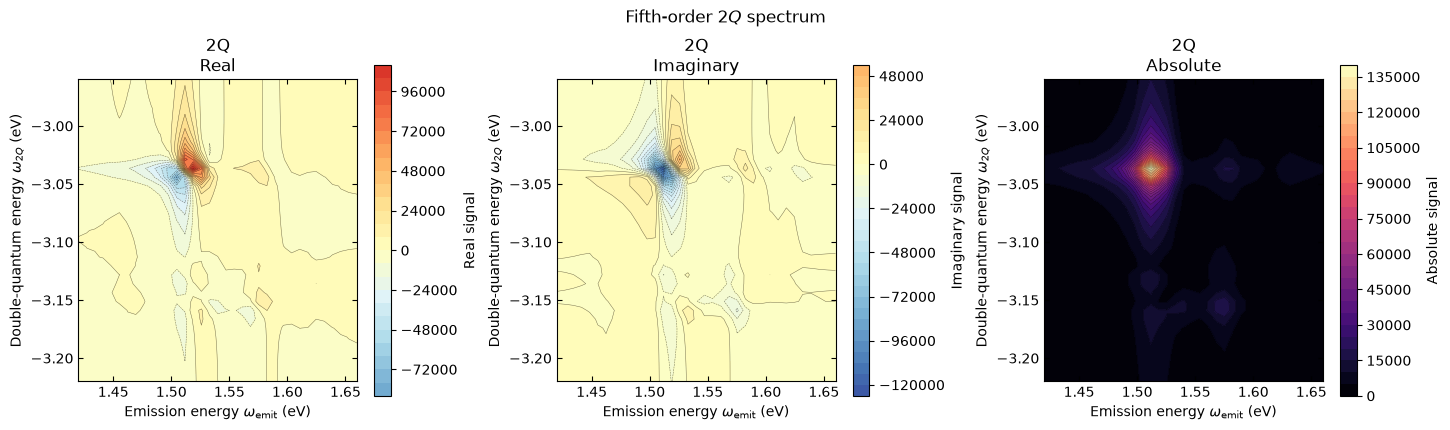

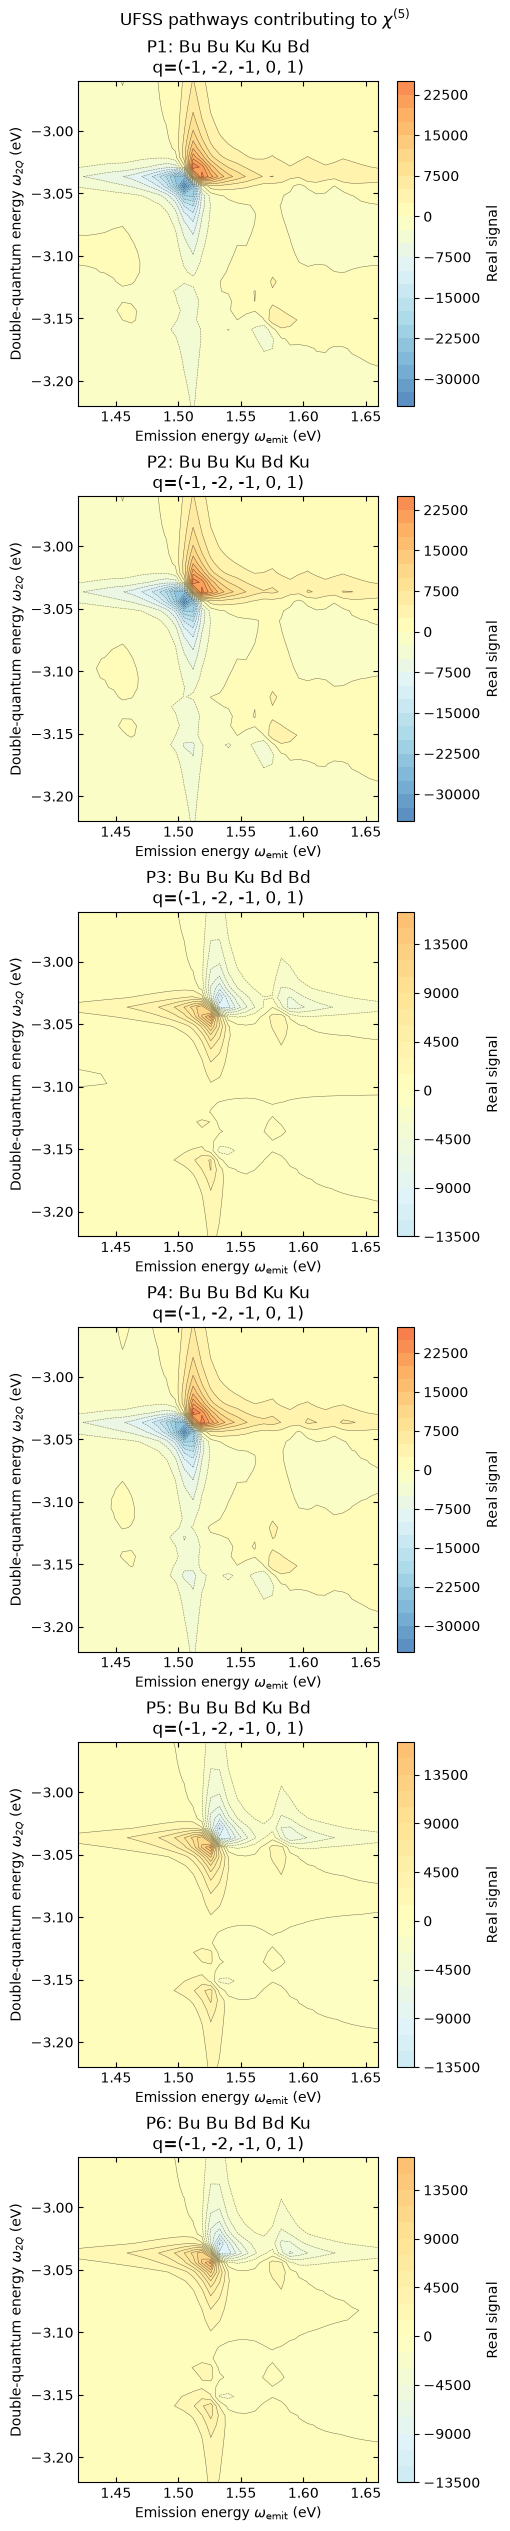

In [8]:
plotter = SpectroscopyPlotter(detection_phase=0.0)

total_plot = plotter.plot_spectrum_result(
    result,
    params={
        "source": "components",
        "names": ["2Q"],
        "view": "all",
        "normalization": "row",
        "labels": (r"Emission energy $\omega_{\mathrm{emit}}$ (eV)", r"Double-quantum energy $\omega_{2Q}$ (eV)"),
        "title": r"Fifth-order $2Q$ spectrum",
        "diagonals": False,
        "style": {"cmap": "RdYlBu_r", "abs_cmap": "magma", "levels": 30},
    },
)

pathway_plot = plotter.plot_pathways(
    result,
    params={
        "pathways": "all",
        "totals": False,
        "view": "real",
        "normalization": "global",
        "labels": (r"Emission energy $\omega_{\mathrm{emit}}$ (eV)", r"Double-quantum energy $\omega_{2Q}$ (eV)"),
        "title": r"UFSS pathways contributing to $\chi^{(5)}$",
        "diagonals": False,
        "style": {"cmap": "RdYlBu_r", "levels": 24},
    },
)

## 8. What this example establishes

1. A biexciton manifold is sufficient to carry the selected $2Q$ coherence.
2. Explicit $J_+$ and $J_-$ preserve a user-defined manifold classification.
3. The response order is determined by the five registered interactions, not by the Hilbert-space dimension.
4. UFSS supplies the allowed ket/bra sequences, while V10 performs their propagation.
5. Several detection operators reuse each propagated pathway state.